In [1]:
import os
os.chdir('./../')
from dotenv import load_dotenv, find_dotenv
env_path = find_dotenv()
load_dotenv(env_path)

True

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import tqdm

In [45]:
sngp_tang_tang =  pd.read_csv('csv/tang_sngp/sngp_tang_tang.csv')
sngp_tang_wong =  pd.read_csv('csv/tang_sngp/sngp_tang_wong.csv')

In [ ]:
# tang_id_to_institution = {}
# tang_data = load_dataset("nirschl-lab/tang_et_al_2019")
# for fold in ['train', 'validation', 'test']:
#     for idx, image_id in enumerate(tqdm.tqdm(tang_data[fold]['image_id'])):
#         institution = tang_data[fold]['institution'][idx]
#         tang_id_to_institution[image_id] = institution
# sngp_tang_tang['institution'] = sngp_tang_tang['image_id'].map(tang_id_to_institution)
# sngp_tang_tang.to_csv('csv/tang_sngp/sngp_tang_tang.csv')

In [ ]:
# wong_id_to_institution = {}
# wong_data = load_dataset("nirschl-lab/wong_et_al_2022")
# for fold in ['train', 'validation', 'test']:
#     for idx, image_id in enumerate(tqdm.tqdm(wong_data[fold]['image_id'])):
#         institution = wong_data[fold]['institution'][idx]
#         wong_id_to_institution[image_id] = institution
# sngp_tang_wong['institution'] = sngp_tang_wong['image_id'].map(wong_id_to_institution)
# sngp_tang_wong.to_csv('csv/tang_sngp/sngp_tang_wong.csv')

100%|██████████| 14010/14010 [00:37<00:00, 374.42it/s]


In [64]:
sngp_tang_wong.head()

,image_id,target,prediction,prediction_prob_score,true_bin_label,class_probs,fold,institution
0,c7a6042e-9160-4526-a77b-268371af5a85,0,3,0.616293,0,"[0.3413248360157013, 0.027427179738879204, 0.0...",train,ucdavis
1,7507a98a-93bd-4b02-9f73-74b3bf8f78cf,2,2,0.996135,1,"[0.0001692460646154359, 0.0028758030384778976,...",train,upitt
2,fc080cc3-9a70-4727-b79e-b6c70f245e49,2,2,0.995669,1,"[0.0001712411904009059, 0.0016002495540305972,...",train,utsouthwestern
3,19ca60a3-dfc5-4fb2-8786-cad67ce20c03,1,2,0.988906,0,"[0.00029194014496169984, 0.009797046892344952,...",train,ucdavis
4,ea84ca60-70a7-45f1-99f7-feafd700c0a4,0,0,0.914810,1,"[0.9148098826408386, 0.022115524858236313, 0.0...",train,upitt


Text(0, 0.5, 'Density')

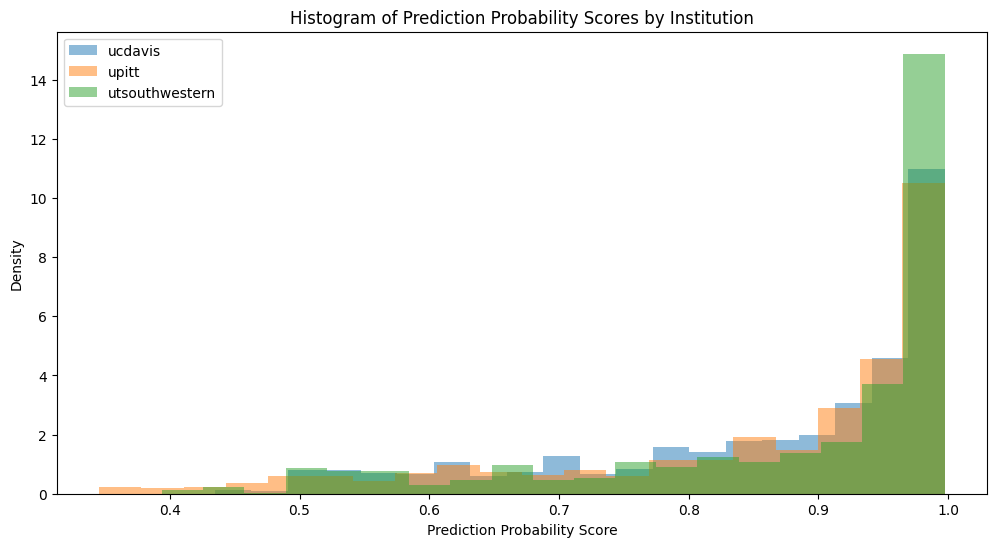

In [69]:
#draw histogram of prediction_prob_score grouped by institution
# make percentage histograms make 10 bins and normalize the histograms to 100%
plt.figure(figsize=(12,6))
sngp_tang_wong.groupby('institution')['prediction_prob_score'].plot(kind='hist', alpha=0.5, legend=True, density=True, bins=20)
plt.title('Histogram of Prediction Probability Scores by Institution')
plt.xlabel('Prediction Probability Score')
plt.ylabel('Density')

In [70]:
#check institution wise accuracy
# target	prediction
sngp_tang_wong['correct'] = sngp_tang_wong['target'] == sngp_tang_wong['prediction']
sngp_tang_wong.groupby('institution')['correct'].mean()

institution
ucdavis           0.697732
upitt             0.608318
utsouthwestern    0.696751
Name: correct, dtype: float64

In [40]:
# tang_id_to_institution
len(tang_id_to_institution)

80873

In [41]:
# add columns for institution
sngp_tang_tang['institution'] = sngp_tang_tang['image_id'].map(tang_id_to_institution)

In [30]:
tang_id_to_institution[sngp_tang_tang.loc[0]['image_id']]

KeyError: '6774146b-822a-45a1-abf8-56fe624ac1a8'